In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Single variable linear regression
Load dane1.txt and examine the structure

In [2]:
import os
path = os.getcwd() + '\dane1.txt'
#TODO read dane1.txt, name columns as Population and Profit
data = pd.read_csv(path, header=None, names=['Population', 'Profit'])

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\MSI\AppData\Local\Temp\ipykernel_17424\39520614.py:2: SyntaxWarning: invalid escape sequence '\d'
  path = os.getcwd() + '\dane1.txt'


Examine loaded data

In [3]:
data.head()

,Population,Profit
0,6.1101,17.5920
1,5.5277,9.1302
2,8.5186,13.6620
3,7.0032,11.8540
4,5.8598,6.8233


In [4]:
data.describe()

,Population,Profit
count,97.000000,97.000000
mean,8.159800,5.839135
std,3.869884,5.510262
min,5.026900,-2.680700
25%,5.707700,1.986900
50%,6.589400,4.562300
75%,8.578100,7.046700
max,22.203000,24.147000


### Examine plotted data

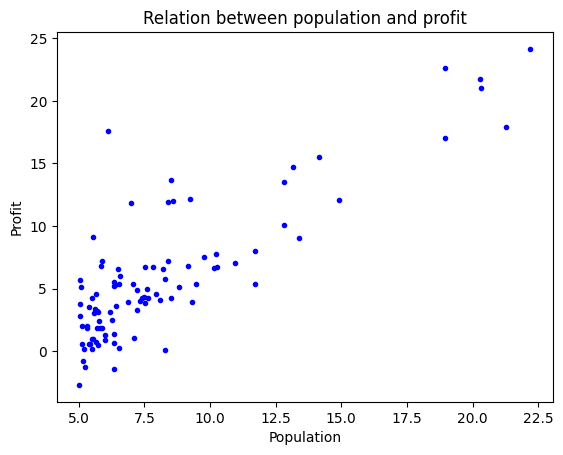

In [5]:
plt.plot(data['Population'], data['Profit'], '.b')
plt.xlabel('Population')
plt.ylabel('Profit')
plt.title('Relation between population and profit')
plt.show()

### Inserting additional column to the dataframe
Insert additional column into dataframe, name it as Cost. Set variable to 1. Make sure that it's present as first column in the dataframe.

In [6]:
#TODO
data.insert(0, 'Cost', 1)

In [7]:
data.head()

,Cost,Population,Profit
0,1,6.1101,17.5920
1,1,5.5277,9.1302
2,1,8.5186,13.6620
3,1,7.0032,11.8540
4,1,5.8598,6.8233


### Splitting x vs y
Split dataframe into two. First resulting dataframe should consist of Cost and Population. Second dataframe will contain Profit only

In [8]:
#TODO
X = data[['Cost', 'Population']]
y = data['Profit']

In [9]:
X.head()

,Cost,Population
0,1,6.1101
1,1,5.5277
2,1,8.5186
3,1,7.0032
4,1,5.8598


In [10]:
#TODO

In [11]:
y.head()

0    17.5920
1     9.1302
2    13.6620
3    11.8540
4     6.8233
Name: Profit, dtype: float64

### Transpose resulting matrices and transform into NumPy array
At this point, the shape of X should be (2,97) and y (1,97)

In [12]:
# Data conversion
X = np.matrix(X.values, dtype=np.float64)
y = np.matrix(y.values, dtype=np.float64)
theta = np.matrix(np.array([0,0]), dtype=np.float64)
# transpose if necessary
if len(X) != 1:
    X = np.transpose(X)
if len(y) != 1:
    y = np.transpose(y)

In [13]:
X.shape

(2, 97)

In [14]:
y.shape

(1, 97)

### Cost function definition
Let's define cost function. \
HINT: compute_cost function should get X,y,theta as input. Final cost is calculated as MSE between X and y

In [15]:
#TODO
def compute_cost(X, y, theta):
    m = X.shape[1]
    h = theta * X
    error = h - y
    squared_error = np.power(error, 2) # np.power - podnoszenie do kwadratu element po elemencie 
    J = np.sum(squared_error) / (2 * m)
    return J

Check initial value of cost function for theta = [0,0]

In [16]:
compute_cost(X, y, theta)

np.float64(32.072733877455676)

### Define gradient descent method
Define gradient descent method. the method should get X,y,theta,alpha (learning rate) and given number of iterations as input. \
The method should collect cost among the iterations and return (cost_list, theta) as a result

In [17]:
def gradient_descent(X, y, theta, alpha, it):
    m = X.shape[1]
    costHist = []
    thetaTemp = theta
    #TODO
    for i in range(it):
        error = thetaTemp * X - y
        gradiet = (error * X.T) / m
        thetaTemp = thetaTemp - alpha * gradiet
        current_cost = compute_cost(X, y, thetaTemp)
        costHist.append(current_cost)
    
    return costHist, thetaTemp

In [18]:
#initial values for learning rate and no. of iterations
alpha = 0.01
it = 1000

cost = gradient_descent(X, y, theta, alpha, it)[0]
theta_result = gradient_descent(X, y, theta, alpha, it)[1]

Check final theta value

In [19]:
theta_result

matrix([[-3.24140214,  1.1272942 ]])

Print optimal cost for final theta value

6.737190464870006

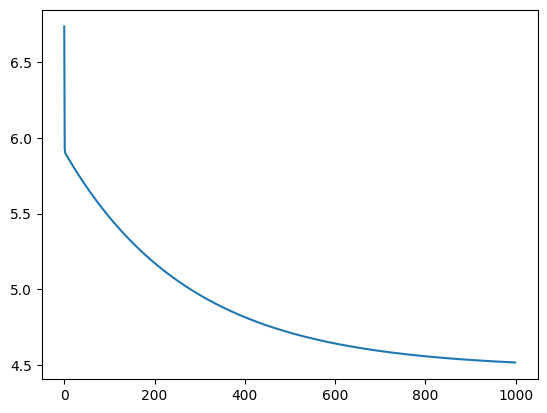

In [20]:
plt.plot(cost)
cost[:][0].item()

### Plot regression line
Calculate predicted values

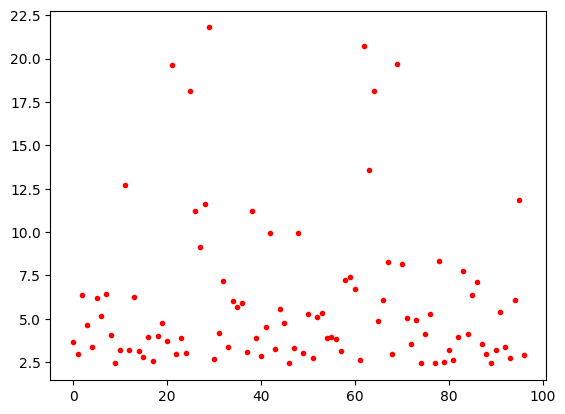

In [21]:
#TODO
y_pred = theta_result * X
y_pred
plt.plot(y_pred.tolist()[0], '.r')

In [22]:
# For plotting purposes only
X = np.squeeze(np.asarray(X[1]))
y = np.squeeze(np.asarray(y)) #Robimy to, żeby można było narysować wykres
y_pred = np.squeeze(np.asarray(y_pred)) #do wykresu trzeba jednowymiarowe tablice a nie macierze 1xN

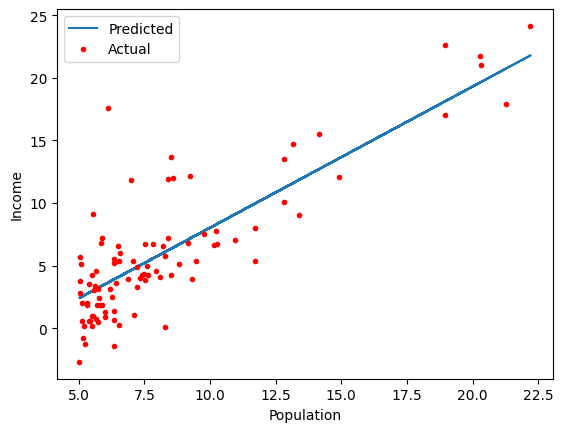

In [23]:
plt.plot(X, y_pred, X, y, 'r.')
plt.xlabel('Population')
plt.ylabel('Income')
plt.legend(['Predicted', 'Actual'])
plt.show()

### Check the relationship between cost function and number of iterations

In [24]:
#TODO initialize iterations according to number of calculated iterations
iterations = range(len(cost))
cost_val = np.squeeze(np.asarray(cost))

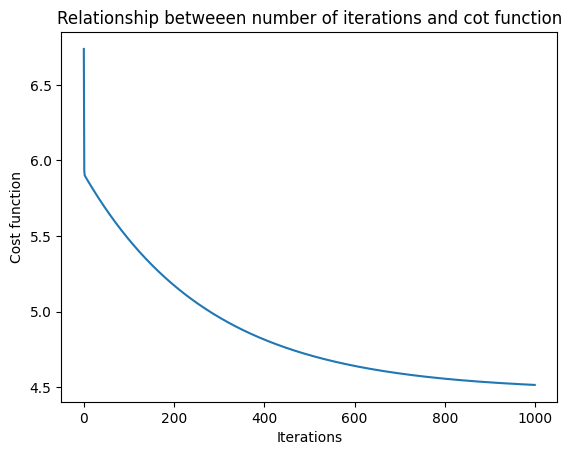

In [25]:
plt.plot(iterations, cost_val)
plt.xlabel('Iterations')
plt.ylabel('Cost function')
plt.title('Relationship betweeen number of iterations and cot function')
plt.show()

# Linear regression with multiple variables
Load dane2.txt \
Analyze the same way as for single variable linear regression

In [26]:
#TODO
path2 = os.getcwd() + '\dane2.txt'
data2 = pd.read_csv(path2, header=None, names=['Size', 'Bedrooms', 'Price'])
data2

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
C:\Users\MSI\AppData\Local\Temp\ipykernel_17424\2153389180.py:2: SyntaxWarning: invalid escape sequence '\d'
  path2 = os.getcwd() + '\dane2.txt'


,Size,Bedrooms,Price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900
5,1985,4,299900
6,1534,3,314900
7,1427,3,198999
8,1380,3,212000
9,1494,3,242500


### Data normalization
HINT: For each column, transform the column with substracting mean and divide the result with column's standard deviation

In [27]:
#TODO
data2 = (data2 - data2.mean()) / data2.std()
data2.head()

,Size,Bedrooms,Price
0,0.130010,-0.223675,0.475747
1,-0.504190,-0.223675,-0.084074
2,0.502476,-0.223675,0.228626
3,-0.735723,-1.537767,-0.867025
4,1.257476,1.090417,1.595389


Insert artificial column for cost calculation

In [28]:
data2.insert(loc=0, column='Cost', value=1, allow_duplicates=False)
data2

,Cost,Size,Bedrooms,Price
0,1,0.130010,-0.223675,0.475747
1,1,-0.504190,-0.223675,-0.084074
2,1,0.502476,-0.223675,0.228626
3,1,-0.735723,-1.537767,-0.867025
4,1,1.257476,1.090417,1.595389
5,1,-0.019732,1.090417,-0.323998
6,1,-0.587240,-0.223675,-0.204036
7,1,-0.721881,-0.223675,-1.130948
8,1,-0.781023,-0.223675,-1.026973
9,1,-0.637573,-0.223675,-0.783051


In [29]:
data2.describe()

,Cost,Size,Bedrooms,Price
count,47.0,4.700000e+01,4.700000e+01,4.700000e+01
mean,1.0,3.779483e-17,2.746030e-16,-9.684924e-17
std,0.0,1.000000e+00,1.000000e+00,1.000000e+00
min,1.0,-1.445423e+00,-2.851859e+00,-1.363666e+00
25%,1.0,-7.155897e-01,-2.236752e-01,-7.238702e-01
50%,1.0,-1.417900e-01,-2.236752e-01,-3.239979e-01
75%,1.0,3.376348e-01,1.090417e+00,3.521863e-01
max,1.0,3.117292e+00,2.404508e+00,2.874981e+00


### Split the data into two parts
First dataframe will contain X (Cost, Size, Bedrooms), second will have Price only

In [30]:
#TODO
X = data2[['Cost', 'Size', 'Bedrooms']]
y = data2['Price']

In [31]:
X.head()

,Cost,Size,Bedrooms
0,1,0.130010,-0.223675
1,1,-0.504190,-0.223675
2,1,0.502476,-0.223675
3,1,-0.735723,-1.537767
4,1,1.257476,1.090417


In [32]:
#TODO

In [33]:
y.head()

0    0.475747
1   -0.084074
2    0.228626
3   -0.867025
4    1.595389
Name: Price, dtype: float64

In [34]:
# Data conversion
X = np.matrix(X.values, dtype=np.float64)
y = np.matrix(y.values, dtype=np.float64)
theta = np.matrix(np.array([0,0,0]), dtype=np.float64)
# transpose if necessary
if len(X) != 1:
    X = np.transpose(X)
if len(y) != 1:
    y = np.transpose(y)

In [35]:
X.shape

(3, 47)

In [36]:
y.shape

(1, 47)

### Reusing const function
Use compute_cost function that was defined for single variable regression purposes

In [37]:
compute_cost(X, y, theta)

np.float64(0.4893617021276595)

### Perform the optimization

In [38]:
#TODO initialize alpha, chose number of iterations
alpha = 0.01
it = 1000

cost = gradient_descent(X, y, theta, alpha, it)[0]
theta_result = gradient_descent(X, y, theta, alpha, it)[1]

Check resulting theta value

In [39]:
theta_result

matrix([[-1.10809707e-16,  8.78503652e-01, -4.69166570e-02]])

Check final cost function

In [40]:
cost[:][0].item()

0.48054910410767177

### Plotting the regression plane
Define a meshgrid for plotting purposes.\
HINT: Bear in mind that the values have been standarized before optimization.

In [42]:
# For plotting purposes only
#TODO
x_range = np.linspace(data2['Size'].min(), data2['Size'].max(), 20)
y_range = np.linspace(data2['Bedrooms'].min(), data2['Bedrooms'].max(), 20)

X1,X2 = np.meshgrid(x_range, y_range)
y = np.squeeze(np.asarray(y))

In [43]:
# calculating predicted values
y_pred = theta_result[0,0] + theta_result[0,1] * X1 + theta_result[0,2] * X2 
y_pred = np.squeeze(np.asarray(y_pred))

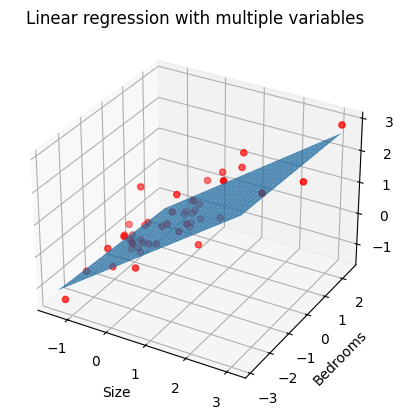

In [45]:
# Create the figure
fig = plt.figure()

# Add an axes
ax = fig.add_subplot(projection='3d')

# plot the surface
ax.plot_surface(X1, X2, y_pred, alpha=0.8)

ax.scatter(data2.Size, data2.Bedrooms, data2.Price, c='r')
plt.title("Linear regression with multiple variables")
ax.set_xlabel('Size')
ax.set_ylabel('Bedrooms')
ax.set_zlabel('Price')
 
# show plot
plt.show()

### Calculate and plot separate regression lines for each feature individually

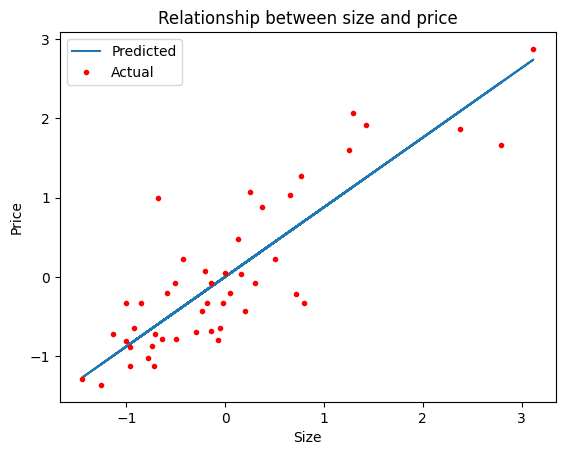

In [48]:
#TODO plot Size vs Price
x_size = data2['Size']
x_rooms = data2['Bedrooms']
y_price = data2['Price']

y_predsize = theta_result[0,0] + theta_result[0,1] * x_size
y_predsize = np.squeeze(np.asarray(y_predsize))

y_predrooms = theta_result[0,0] + theta_result[0,2] * x_rooms
y_predrooms = np.squeeze(np.asarray(y_predrooms))

plt.plot(x_size, y_predsize, x_size, y_price, 'r.')
plt.xlabel('Size')
plt.ylabel('Price')
plt.legend(['Predicted', 'Actual'])
plt.title('Relationship between size and price')
plt.show()


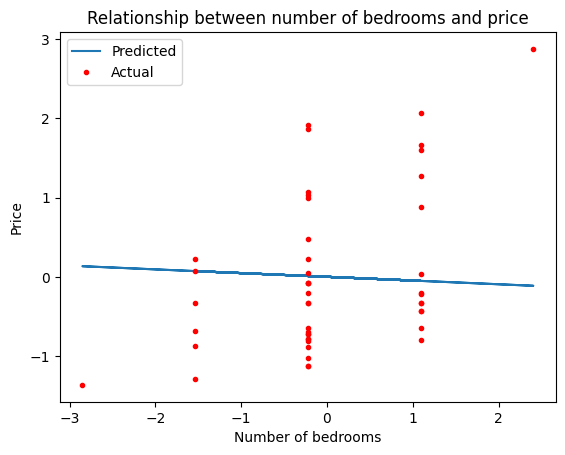

In [49]:
#TODO plot Bedrooms vs Price
plt.plot(x_rooms, y_predrooms, x_rooms, y_price, 'r.')
plt.xlabel('Number of bedrooms')
plt.ylabel('Price')
plt.legend(['Predicted', 'Actual'])
plt.title('Relationship between number of bedrooms and price')
plt.show()

# Linear regression using python libraries

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets, linear_model as linm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [53]:
# Load the california housing dataset dataset
california = datasets.fetch_california_housing()
# print description
print(california.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

Split the data into data and target

In [54]:
#TODO
california_X = california.data
california_Y = california.target

Standarize values

In [ ]:
#TODO
california_X = (california_X - california_X.mean(axis=0)) / california_X.std(axis=0)
california_Y = (california_Y - california_Y.mean()) / california_Y.std()

### Splitting into train, test datasets 

In [55]:
#TODO split using test_size
X_train, X_test, y_train, y_test = train_test_split(california_X, california_Y, test_size=0.2, random_state=42)

print(f"Całość: {california_X.shape}")
print(f"Trening: {X_train.shape}")
print(f"Test: {X_test.shape}")

Całość: (20640, 8)
Trening: (16512, 8)
Test: (4128, 8)


### Initialize the object

In [ ]:
regr = linm.LinearRegression() #budowanie maszyny która bedzie się uczyć na naszych danych

In [ ]:
#TODO run the training
regr.fit(X_train, y_train) # trenujemy model(nasza maszyne) na danych treningowych

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
regr.coef_ #to sa wspołczynniki juz po treningu

array([ 4.48674910e-01,  9.72425752e-03, -1.23323343e-01,  7.83144907e-01,
       -2.02962058e-06, -3.52631849e-03, -4.19792487e-01, -4.33708065e-01])

In [ ]:
regr.intercept_ #to jest wyraz wolny, czyli to co jest dodawane do wyniku mnożenia współczynników przez cechy (przeciecie z osią Y)

np.float64(-37.02327770606397)

Get the predictions after learning phase

In [63]:
#TODO
Y_predicted = regr.predict(X_test)

Check theta

In [64]:
print('Coefficients: \n', regr.coef_)

Coefficients: 
 [ 4.48674910e-01  9.72425752e-03 -1.23323343e-01  7.83144907e-01
 -2.02962058e-06 -3.52631849e-03 -4.19792487e-01 -4.33708065e-01]


Check regression MSE

In [65]:
error = np.mean((regr.predict(X_test) - y_test) ** 2)
print("Residual sum of squares: {}".format(error))

Residual sum of squares: 0.5558915986952425


Calculate R2 score

In [66]:
#TODO
r2 = r2_score(y_test, Y_predicted)
r2

0.5757877060324521

Check out available MSE calculation function from sklearn.metrics

In [67]:
#TODO
mse = mean_squared_error(y_test, Y_predicted)
mse

0.5558915986952425

Plot linear regression line for chosen subset of features, e.g. MedInc vs target (actual and predicted). Use at least 3 features

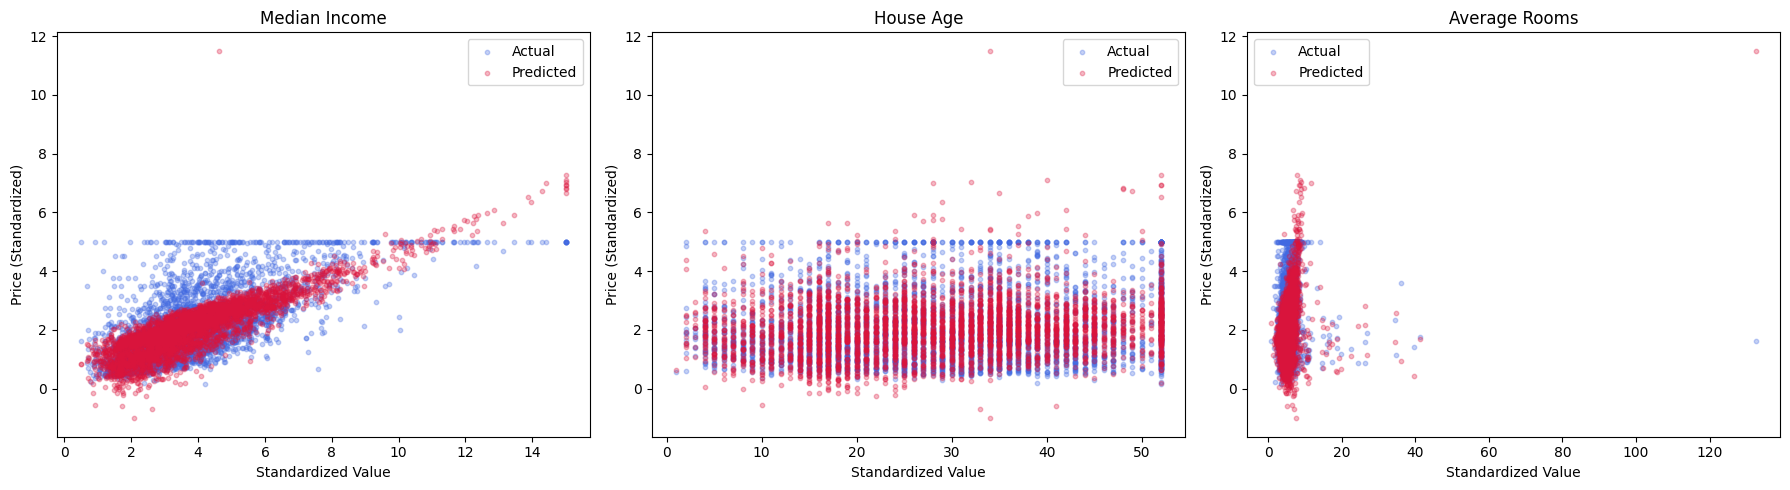

In [68]:
#TODO
features_to_plot = [0, 1, 2] 
feature_titles = ['Median Income', 'House Age', 'Average Rooms']

plt.figure(figsize=(18, 5))

for i, feature_idx in enumerate(features_to_plot):
    plt.subplot(1, 3, i + 1)
    
    # Wybieramy dane dla konkretnej cechy z X_test
    x_values = X_test[:, feature_idx]
    
    # Rysujemy prawdziwe wartości (niebieskie kropki)
    plt.scatter(x_values, y_test, color='royalblue', alpha=0.3, label='Actual', s=10)
    
    # Rysujemy przewidziane wartości (czerwone kropki/linia)
    # Używamy scatter, bo dla Multiple Regression przewidywania nie tworzą idealnej linii w 2D
    plt.scatter(x_values, Y_predicted, color='crimson', alpha=0.3, label='Predicted', s=10)
    
    plt.title(feature_titles[i])
    plt.xlabel('Standardized Value')
    plt.ylabel('Price (Standardized)')
    plt.legend()

plt.tight_layout()
plt.show()